In [26]:
from python_files.huffman import huffman
import matplotlib.pyplot as plt
import numpy as np
import cv2 as cv

img = cv.imread("Aula_1_files/aula1.bmp", 0)

Ex 1

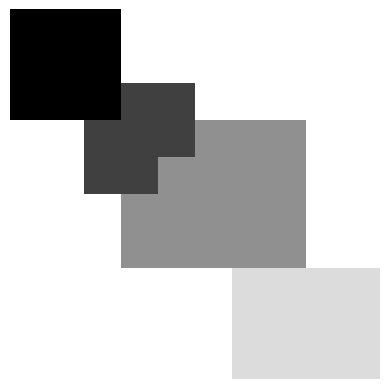

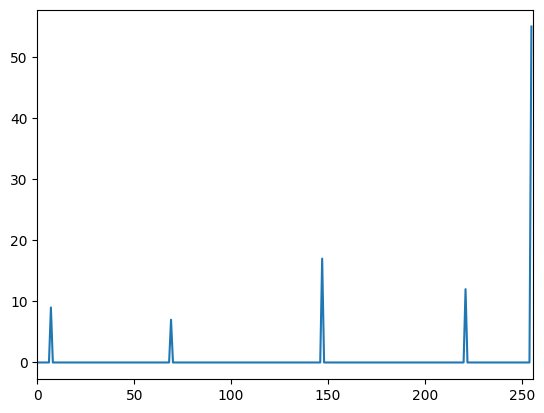

In [27]:
plt.imshow(img, cmap="gray")
plt.axis("off")
plt.show()

hist = cv.calcHist([img],[0],None,[256],[0,256])

plt.plot(hist), plt.xlim([0, 256])
plt.show()

Ex 2

In [28]:
flat_img = img.flatten()

flat_image_bin = ''.join(list(map(lambda x: f"{x:08b}", flat_img)))
print(f"Uncompressed image: {flat_image_bin}")
print(f"Uncompressed image bit length {len(flat_image_bin)}")

Uncompressed image: 00000111000001110000011111111111111111111111111111111111111111111111111111111111000001110000011100000111111111111111111111111111111111111111111111111111111111110000011100000111000001110100010101000101111111111111111111111111111111111111111111111111111111110100010101000101010001011001001110010011100100111111111111111111111111111111111101000101010001011001001110010011100100111001001111111111111111111111111111111111111111111001001110010011100100111001001110010011111111111111111111111111111111111111111110010011100100111001001110010011100100111111111111111111111111111111111111111111111111111111111111111111110111011101110111011101110111011111111111111111111111111111111111111111111111111101110111011101110111011101110111111111111111111111111111111111111111111111111111011101110111011101110111011101
Uncompressed image bit length 800


Ex 3

3.2

In [29]:
huffman_dict = huffman(flat_img)
display(dict(sorted(huffman_dict.items(), key = lambda x: len(x[1]))))

{np.uint8(255): '1',
 np.uint8(147): '00',
 np.uint8(221): '010',
 np.uint8(69): '0110',
 np.uint8(7): '0111'}

3.4

In [30]:
def compress_img(huffman_dict: dict, img: list) -> str:
    
    final_bit_str: str = f"{len(huffman_dict.keys()):08b}"
    code_bits_dimension = int(len(bin(max(list(map(lambda x: len(x), huffman_dict.values()))))) - 2)
    final_bit_str += f"{code_bits_dimension:08b}" 

    sorted_dict = dict(sorted(huffman_dict.items(), key = lambda x: x[0]))

    for k, i in sorted_dict.items():
        final_bit_str += f"{k:08b}{int(i, 2):0{code_bits_dimension}b}"

    for i in img:
        final_bit_str += f"{int(sorted_dict.get(i), 2):0{code_bits_dimension}b}"

    return final_bit_str

compressed = compress_img(huffman_dict, flat_img)
print(f"Compressed image: {compressed}")
print(f"Compressed image bit length: {len(compressed)}")

Compressed image: 00000101000000110000011111101000101110100100110001101110101011111111001111111111001001001001001001001111111111001001001001001001001111111111110110001001001001001001001110110110000000000001001001001110110000000000000001001001001001000000000000000001001001001001000000000000000001001001001001001001001010010010010001001001001001001010010010010001001001001001001010010010010
Compressed image bit length: 371


Ex 4

In [31]:
print(f"Compression ratio (Uncompressed/Compressed): {len(flat_image_bin)/len(compressed)}")

Compression ratio (Uncompressed/Compressed): 2.1563342318059298


Ex 7

In [32]:
def entropy(img):
    
    total_entropy = np.array([])

    for i in range(3):
        histogram = np.array(cv.calcHist([img],[i],None,[256],[0,256]))
        total_inst = np.sum(histogram)

        histogram = histogram/total_inst

        histogram = histogram[histogram != 0]

        total_entropy = np.append(total_entropy, np.sum(-histogram*np.log2(histogram)))

    return total_entropy

EX 8

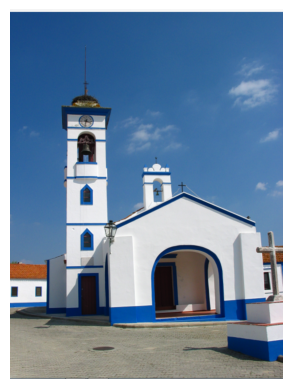

Blue channel entropy: 7.505908012390137
Green channel entropy: 7.295637130737305
Red channel entropy: 7.125


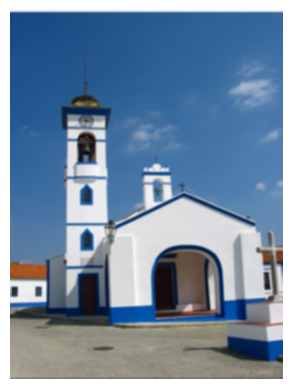

Blue channel entropy: 7.503604888916016
Green channel entropy: 7.263134479522705
Red channel entropy: 7.126522541046143


In [33]:
img1 = cv.imread("Aula_1_files/Picture1.png")
img1 = cv.cvtColor(img1, cv.COLOR_BGR2RGB)

plt.imshow(img1)
plt.axis('off')
plt.show()

entropy_per_channel = entropy(img1)

print(f"Blue channel entropy: {entropy_per_channel[0]}")
print(f"Green channel entropy: {entropy_per_channel[1]}")
print(f"Red channel entropy: {entropy_per_channel[2]}")

kernel = np.ones((5,5),np.float32)/25
dst = cv.filter2D(img1,-1,kernel)

plt.imshow(dst)
plt.axis('off')
plt.show()

entropy_per_channel = entropy(dst)

print(f"Blue channel entropy: {entropy_per_channel[0]}")
print(f"Green channel entropy: {entropy_per_channel[1]}")
print(f"Red channel entropy: {entropy_per_channel[2]}")